In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [15]:
df = pd.read_csv('../data/euromillions.csv')

df = df.rename(columns={
    "date (dd-mm-yyyy)": "date",
    "jackpot (in EUR)": "jackpot"
})
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")
df = df.sort_values("date")

df.head()

,date,num_1,num_2,num_3,num_4,num_5,star_1,star_2,jackpot
0,2004-02-13,16,29,32,36,41,7,9,15000000
1,2004-02-20,7,13,39,47,50,2,5,15000000
2,2004-02-27,14,18,19,31,37,4,5,17750473
3,2004-03-05,4,7,33,37,39,1,5,20678070
4,2004-03-12,15,24,28,44,47,4,5,15000000


In [16]:
df["num_1_odd"] = df["num_1"] % 2
df["num_2_odd"] = df["num_2"] % 2
df["num_3_odd"] = df["num_3"] % 2
df["num_4_odd"] = df["num_4"] % 2
df["num_5_odd"] = df["num_5"] % 2

df["odd_count"] = (
    df["num_1_odd"] +
    df["num_2_odd"] +
    df["num_3_odd"] +
    df["num_4_odd"] +
    df["num_5_odd"]
)

df['odd_leaning'] = 0

df.loc[df['odd_count'] >= 3, 'odd_leaning'] = 1

df[["num_1", "num_2", "num_3", "num_4", "num_5", "odd_count", "odd_leaning"]].head()

,num_1,num_2,num_3,num_4,num_5,odd_count,odd_leaning
0,16,29,32,36,41,2,0
1,7,13,39,47,50,4,1
2,14,18,19,31,37,3,1
3,4,7,33,37,39,4,1
4,15,24,28,44,47,2,0


In [17]:
df["prev_num_1"] = df["num_1"].shift(1)
df["prev_num_2"] = df["num_2"].shift(1)
df["prev_num_3"] = df["num_3"].shift(1)
df["prev_num_4"] = df["num_4"].shift(1)
df["prev_num_5"] = df["num_5"].shift(1)

df["prev_star_1"] = df["star_1"].shift(1)
df["prev_star_2"] = df["star_2"].shift(1)

df["prev_jackpot"] = df["jackpot"].shift(1)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df_model = df.dropna()

In [18]:
features = [
    "prev_num_1",
    "prev_num_2",
    "prev_num_3",
    "prev_num_4",
    "prev_num_5",
    "prev_star_1",
    "prev_star_2",
    "prev_jackpot",
    "year",
    "month"
]

X = df_model[features]
y = df_model["odd_leaning"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
predictions = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.5012919896640827
Precision: 0.5164835164835165
Recall: 0.698019801980198
F1 Score: 0.5936842105263158


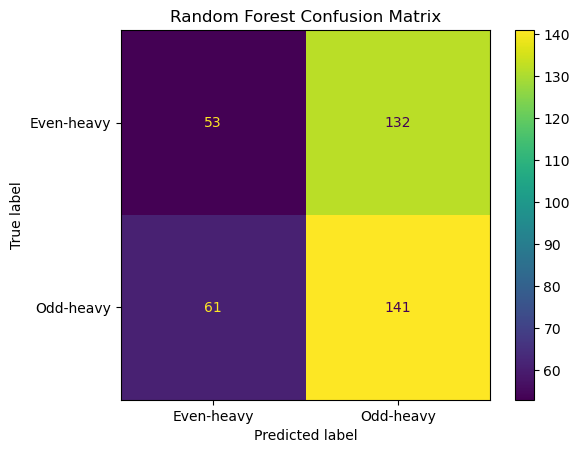

In [20]:
matrix = confusion_matrix(y_test, predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["Even-heavy", "Odd-heavy"]
)

display.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

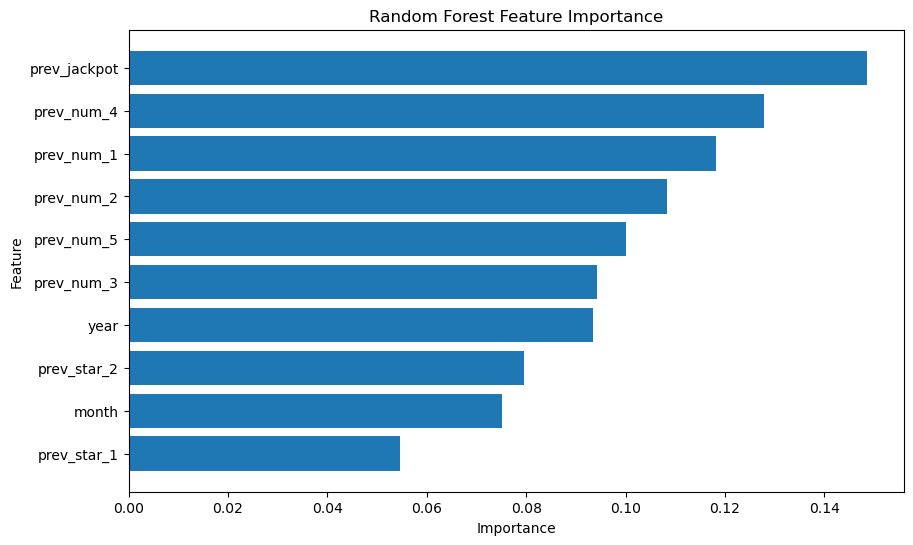

In [21]:
importance_values = rf_model.feature_importances_

importance_table = pd.DataFrame({
    "Feature": features,
    "Importance": importance_values
})

importance_table = importance_table.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_table["Feature"], importance_table["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

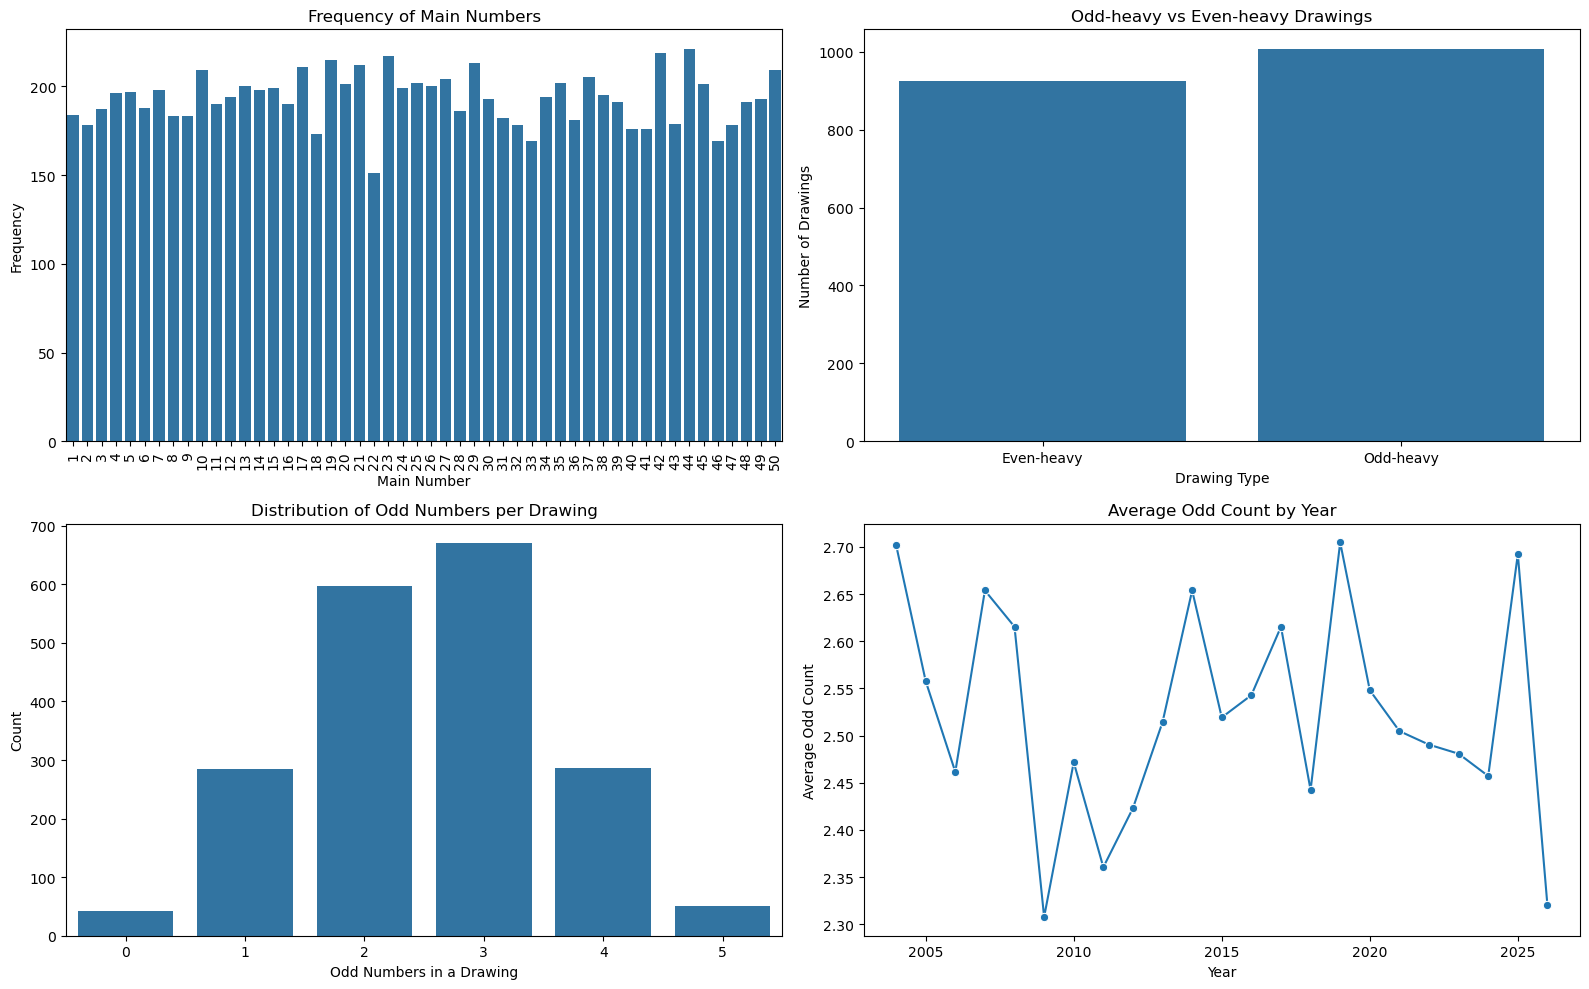

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

main_numbers = ["num_1", "num_2", "num_3", "num_4", "num_5"]
star_numbers = ["star_1", "star_2"]


df["even_count"] = 5 - df["odd_count"]

df["odd_leaning"] = 0
df.loc[df["odd_count"] >= 3, "odd_leaning"] = 1

df["main_range"] = df[main_numbers].max(axis=1) - df[main_numbers].min(axis=1)
df["year"] = df["date"].dt.year

main_numbers_all = pd.concat([
    df["num_1"],
    df["num_2"],
    df["num_3"],
    df["num_4"],
    df["num_5"]
])

main_freq = main_numbers_all.value_counts().sort_index()

main_freq_df = pd.DataFrame({
    "Number": main_freq.index,
    "Frequency": main_freq.values
})

target_counts = df["odd_leaning"].value_counts().sort_index()

target_counts_df = pd.DataFrame({
    "Pattern": ["Even-heavy", "Odd-heavy"],
    "Count": [target_counts[0], target_counts[1]]
})

yearly_odd = df.groupby("year")["odd_count"].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Main number frequencies
sns.barplot(
    data=main_freq_df,
    x="Number",
    y="Frequency",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Frequency of Main Numbers")
axes[0, 0].set_xlabel("Main Number")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].tick_params(axis="x", rotation=90)

sns.barplot(
    data=target_counts_df,
    x="Pattern",
    y="Count",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Odd-heavy vs Even-heavy Drawings")
axes[0, 1].set_xlabel("Drawing Type")
axes[0, 1].set_ylabel("Number of Drawings")

sns.countplot(
    data=df,
    x="odd_count",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Distribution of Odd Numbers per Drawing")
axes[1, 0].set_xlabel("Odd Numbers in a Drawing")
axes[1, 0].set_ylabel("Count")

sns.lineplot(
    data=yearly_odd,
    x="year",
    y="odd_count",
    marker="o",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Average Odd Count by Year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Average Odd Count")

plt.tight_layout()
plt.show()